# Computación Cuántica: Lista de Ejercicios 01
**Docente: Raul Huillca Huallparimachi**  
**Curso: Computación Cuántica**  
**29/08/2025**

---
## 1. Reconocer vectores de probabilidad

Sea $\Sigma = \{0,1,2,\ldots,9\}$ el conjunto de estados clásicos de un sistema que representa un solo dígito.

**¿Cuáles de los siguientes vectores son vectores de probabilidad?** Justifique su respuesta.

1. $\frac{2}{5}|8\rangle+\frac{1}{5}\left(|3\rangle+|4\rangle+|5\rangle\right)$
2. $\frac{3}{2}|0\rangle+\frac{1}{2}|1\rangle-|0\rangle$
3. $\frac{1}{10}\sum_{j=1}^{9}|j\rangle$
4. $(1-\sqrt{2})|7\rangle+\sqrt{2}|2\rangle$
5. $\frac{1}{3}|3\rangle+\frac{1}{4}|4\rangle+\frac{5}{12}|5\rangle$

v1 es prob vector: True
v2 es prob vector: True
v3 es prob vector: False (Suma es 0.9)
v4 es prob vector: False (Tiene negativos)
v5 es prob vector: True


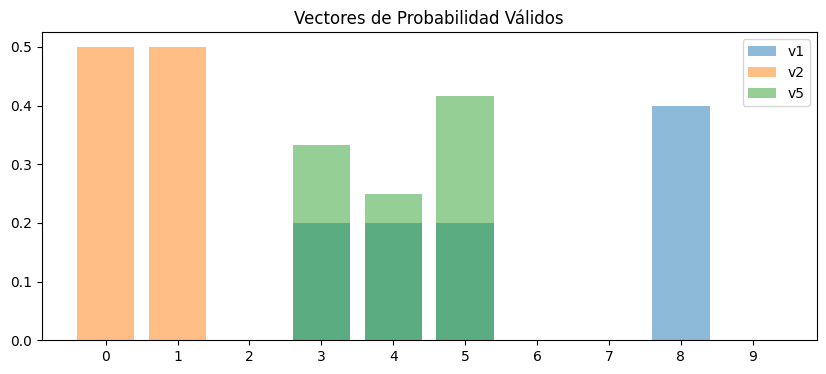

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ejercicio 1: Reconocer vectores de probabilidad
# Para ser un vector de probabilidad, todas sus entradas deben ser >= 0 y sumar 1.

def is_prob_vector(v):
    return np.all(v >= 0) and np.isclose(np.sum(v), 1.0)

# 1. 2/5|8> + 1/5|3> + 1/5|4> + 1/5|5>
v1 = np.zeros(10)
v1[8] = 2/5; v1[3] = 1/5; v1[4] = 1/5; v1[5] = 1/5
print(f"v1 es prob vector: {is_prob_vector(v1)}")

# 2. 3/2|0> + 1/2|1> - |0> = 1/2|0> + 1/2|1>
v2 = np.zeros(10)
v2[0] = 1/2; v2[1] = 1/2
print(f"v2 es prob vector: {is_prob_vector(v2)}")

# 3. 1/10 sum_{j=1}^{9} |j> -> Suma solo tiene 9 elementos
v3 = np.zeros(10)
for j in range(1, 10): v3[j] = 1/10
print(f"v3 es prob vector: {is_prob_vector(v3)} (Suma es {np.sum(v3)})")

# 4. (1-sqrt(2))|7> + sqrt(2)|2>
v4 = np.zeros(10)
v4[7] = 1 - np.sqrt(2); v4[2] = np.sqrt(2)
print(f"v4 es prob vector: {is_prob_vector(v4)} (Tiene negativos)")

# 5. 1/3|3> + 1/4|4> + 5/12|5>
v5 = np.zeros(10)
v5[3] = 1/3; v5[4] = 1/4; v5[5] = 5/12
print(f"v5 es prob vector: {is_prob_vector(v5)}")

# Plotting the valid probability vectors
plt.figure(figsize=(10, 4))
plt.bar(range(10), v1, alpha=0.5, label='v1')
plt.bar(range(10), v2, alpha=0.5, label='v2')
plt.bar(range(10), v5, alpha=0.5, label='v5')
plt.legend()
plt.title('Vectores de Probabilidad Válidos')
plt.xticks(range(10))
plt.savefig('ej1_prob_vectors.png')
plt.show()


---
## 2. Reconocer matrices estocásticas

Las siguientes matrices son todas matrices de $3\times3$.

**Seleccione todas aquellas que sean matrices estocásticas.**

1. $|0\rangle\langle0|+|1\rangle\langle1|-|2\rangle\langle2|$
2. $\begin{pmatrix} \frac13 & \frac13 & \frac13\\ \frac14 & \frac{5}{12} & \frac13\\ \frac{5}{12} & \frac13 & \frac14 \end{pmatrix}$
3. $\begin{pmatrix} 0 & 1 & 0\\ 0 & 0 & 1\\ 1 & 0 & 0 \end{pmatrix}$
4. $\frac13\left(|0\rangle+|1\rangle+|2\rangle\right) \left(\langle0|+\langle1|+\langle2|\right)$
5. $\begin{pmatrix} 1 & 1 & 0\\ 0 & 0 & 1\\ 1 & 0 & 0 \end{pmatrix}$
6. $\begin{pmatrix} 1 & 0 & 0\\ 1 & 0 & 0\\ 0 & 1 & 0 \end{pmatrix}$

M1 es estocástica: False
M2 es estocástica: True
M3 es estocástica: True
M4 es estocástica: True
M5 es estocástica: False
M6 es estocástica: True


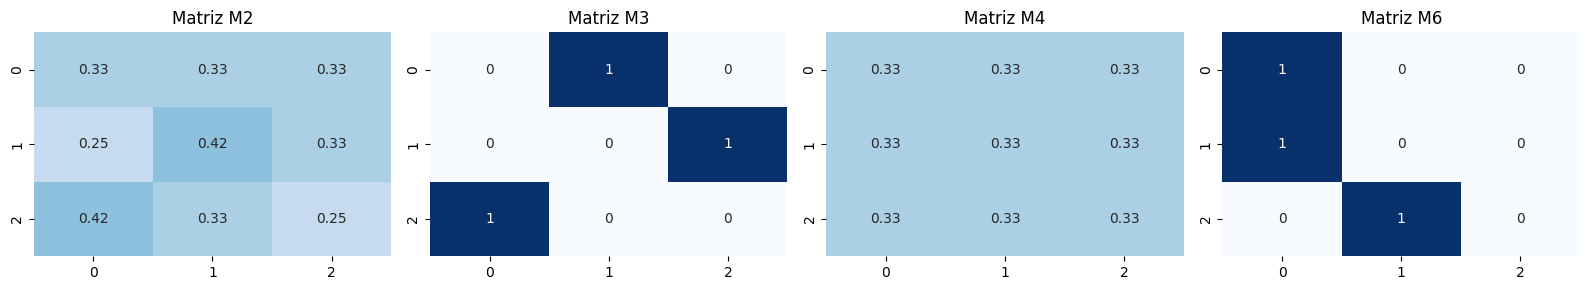

In [2]:
# Ejercicio 2: Reconocer matrices estocásticas
import seaborn as sns

def is_stochastic(M):
    return np.all(M >= 0) and np.allclose(np.sum(M, axis=1), 1.0)

M1 = np.diag([1, 1, -1])
M2 = np.array([[1/3, 1/3, 1/3], [1/4, 5/12, 1/3], [5/12, 1/3, 1/4]])
M3 = np.array([[0, 1, 0], [0, 0, 1], [1, 0, 0]])
M4 = (1/3) * np.ones((3, 3))
M5 = np.array([[1, 1, 0], [0, 0, 1], [1, 0, 0]])
M6 = np.array([[1, 0, 0], [1, 0, 0], [0, 1, 0]])

matrices = [M1, M2, M3, M4, M5, M6]
valid_indices = []

for i, M in enumerate(matrices):
    print(f"M{i+1} es estocástica: {is_stochastic(M)}")
    if is_stochastic(M):
        valid_indices.append(i)

# Plotting valid matrices as heatmaps
fig, axes = plt.subplots(1, len(valid_indices), figsize=(4*len(valid_indices), 3))
for idx, ax in zip(valid_indices, axes):
    sns.heatmap(matrices[idx], annot=True, cmap="Blues", cbar=False, ax=ax, vmin=0, vmax=1)
    ax.set_title(f'Matriz M{idx+1}')
plt.tight_layout()
plt.savefig('ej2_stochastic_matrices.png')
plt.show()


---
## 3. Convertir matriz a notación de Dirac

Sean $|0\rangle$ y $|1\rangle$ los vectores base estándar para un solo qubit:

$$|0\rangle= \begin{pmatrix} 1\\ 0 \end{pmatrix}, \qquad |1\rangle= \begin{pmatrix} 0\\ 1 \end{pmatrix}$$

¿Cuál de las siguientes es una representación correcta de la matriz

$$M= \begin{pmatrix} 2 & -1\\ -9 & 3 \end{pmatrix}$$

en notación de Dirac? **Demuestre todas las opciones.**

1. $M= 2(2|0\rangle-|1\rangle) (-9\langle0|+3\langle1|)$
2. $M= 2|0\rangle\langle0| -|0\rangle\langle1| -9|1\rangle\langle0| +3|1\rangle\langle1|$
3. $M= 2|1\rangle\langle1| -|0\rangle\langle1| -9|1\rangle\langle0| +3|0\rangle\langle0|$
4. $M= 2|0\rangle\langle0| -|1\rangle\langle0| -9|0\rangle\langle1| +3|1\rangle\langle1|$
5. $M= 2|00\rangle\langle00| -|01\rangle\langle01| -9|10\rangle\langle10| +3|11\rangle\langle11|$

In [3]:
# Ejercicio 3: Convertir matriz a notación de Dirac
M = np.array([[2, -1], [-9, 3]])
print("Matriz M:\n", M)

# Opcion 2 es correcta:
opc2 = 2*np.outer([1,0], [1,0]) - 1*np.outer([1,0], [0,1]) - 9*np.outer([0,1], [1,0]) + 3*np.outer([0,1], [0,1])
print("\nOpción 2 evaluada:\n", opc2)
print("\n¿Coincide la opción 2 con M?", np.allclose(M, opc2))


Matriz M:
 [[ 2 -1]
 [-9  3]]

Opción 2 evaluada:
 [[ 2 -1]
 [-9  3]]

¿Coincide la opción 2 con M? True


---
## 4. Reconocer vectores de estados cuánticos

Sea $\Sigma=\{\#,b,c\}$ el conjunto de estados clásicos de un sistema.

**¿Cuáles de los siguientes son vectores de estados cuánticos?** Seleccione todas las que correspondan.

1. $\frac12 \left( \sqrt6\,|\#\rangle -\sqrt2\,|b\rangle +2i\,|c\rangle \right)$
2. $\sqrt{\frac{i}{3}}\,|c\rangle +\sqrt{\frac12}\,|\#\rangle +\sqrt{\frac16}\,|b\rangle$
3. $\frac12 \left( \sqrt2\,|c\rangle -\sqrt{\frac23}\,|\#\rangle +\sqrt{\frac{2i}{3}}\,|b\rangle \right)$
4. $\frac{i-\sqrt3}{2\sqrt3}\,|c\rangle +\sqrt{\frac{1-i}{12}}\,|b\rangle +\sqrt{\frac12}\,|\#\rangle$

Estado 1 es válido: False (Norma al cuadrado: 3.0000)
Estado 2 es válido: True (Norma al cuadrado: 1.0000)
Estado 3 es válido: False (Norma al cuadrado: 0.8333)
Estado 4 es válido: False (Norma al cuadrado: 0.9512)


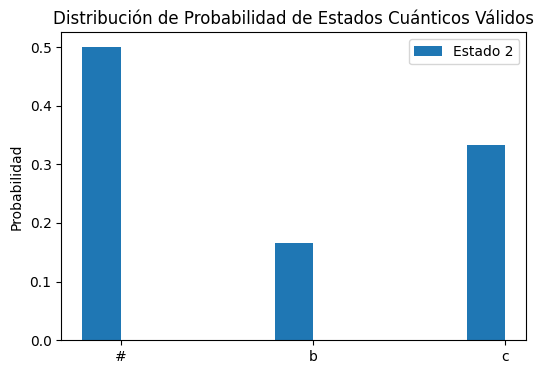

In [4]:
# Ejercicio 4: Vectores de estado cuántico (Norma = 1)
def is_quantum_state(v):
    norm_sq = np.sum(np.abs(v)**2)
    return np.isclose(norm_sq, 1.0)

# 1. (1/2) * (sqrt(6)|#> - sqrt(2)|b> + 2i|c>)
v1 = 0.5 * np.array([np.sqrt(6), -np.sqrt(2), 2j])

# 2. sqrt(i/3)|c> + sqrt(1/2)|#> + sqrt(1/6)|b>
# Orden: #, b, c
v2 = np.array([np.sqrt(1/2), np.sqrt(1/6), np.sqrt(1j/3)])

# 3. (1/2) * (-sqrt(2/3)|#> + sqrt(2i/3)|b> + sqrt(2)|c>)
v3 = 0.5 * np.array([-np.sqrt(2/3), np.sqrt(2j/3), np.sqrt(2)])

# 4. (i-sqrt(3))/(2*sqrt(3))|c> + sqrt((1-i)/12)|b> + sqrt(1/2)|#>
v4 = np.array([np.sqrt(1/2), np.sqrt((1-1j)/12), (1j-np.sqrt(3))/(2*np.sqrt(3))])

states = [v1, v2, v3, v4]
probs = []
labels = []
for i, v in enumerate(states):
    valid = is_quantum_state(v)
    print(f"Estado {i+1} es válido: {valid} (Norma al cuadrado: {np.sum(np.abs(v)**2):.4f})")
    if valid:
        probs.append(np.abs(v)**2)
        labels.append(f'Estado {i+1}')

plt.figure(figsize=(6, 4))
x = np.arange(3)
width = 0.2
for i, p in enumerate(probs):
    plt.bar(x + i*width, p, width, label=labels[i])
plt.xticks(x + width/2, ['#', 'b', 'c'])
plt.ylabel('Probabilidad')
plt.title('Distribución de Probabilidad de Estados Cuánticos Válidos')
plt.legend()
plt.savefig('ej4_quantum_states.png')
plt.show()


---
## 5. Orden alfabético de productos cartesianos

Sea $\Gamma=\{1,2,3,4\}$ ordenado como está escrito, con $1$ primero.

**¿Cuál es el elemento número 12 del conjunto $\Gamma\times\Gamma$ ordenado alfabéticamente?**

In [5]:
import itertools
# Ejercicio 5: Producto cartesiano
Gamma = [1, 2, 3, 4]
cartesian = list(itertools.product(Gamma, Gamma))

print("Elemento número 12 (índice 11):", cartesian[11])


Elemento número 12 (índice 11): (3, 4)


---
## 6. Calcular productos tensoriales

Se tienen los siguientes vectores:

$$|u\rangle= \begin{pmatrix} -2\\ 1 \end{pmatrix}$$
$$|v\rangle= \begin{pmatrix} 1\\ 0\\ 1 \end{pmatrix}$$
$$|w\rangle= \begin{pmatrix} 4\\ 1 \end{pmatrix}$$
$$|x\rangle= \begin{pmatrix} \frac12\\ \frac12\\ \frac12 \end{pmatrix}$$

Calcular el siguiente producto tensorial:

$$|u\rangle\otimes|v\rangle -\frac{2}{3} |w\rangle\otimes|x\rangle$$

In [6]:
# Ejercicio 6: Producto tensorial
u = np.array([[-2], [1]])
v = np.array([[1], [0], [1]])
w = np.array([[4], [1]])
x = np.array([[1/2], [1/2], [1/2]])

term1 = np.kron(u, v)
term2 = (2/3) * np.kron(w, x)

result = term1 - term2
print("Resultado del producto tensorial:")
print(result)


Resultado del producto tensorial:
[[-3.33333333]
 [-1.33333333]
 [-3.33333333]
 [ 0.66666667]
 [-0.33333333]
 [ 0.66666667]]
